In [1]:
import os
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

'''
Datasets for sandbox were downloaded from kaggle
'''

df = pd.read_csv('social_media_productivity_6000.csv')

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    5880 non-null   float64
 1   daily_screen_time      5880 non-null   float64
 2   social_media_hours     5880 non-null   float64
 3   study_hours            5880 non-null   float64
 4   sleep_hours            5880 non-null   float64
 5   notifications_per_day  5880 non-null   float64
 6   focus_score            5880 non-null   float64
 7   addiction_level        5880 non-null   str    
 8   productivity_score     5880 non-null   float64
dtypes: float64(8), str(1)
memory usage: 450.8 KB


In [5]:
df.describe()

,age,daily_screen_time,social_media_hours,study_hours,sleep_hours,notifications_per_day,focus_score,productivity_score
count,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000
mean,27.111395,6.923175,4.145915,4.069328,6.514270,159.781463,96.363531,37.614051
std,7.268430,2.859055,2.155496,2.309472,1.434351,81.044666,7.416839,27.603251
min,15.000000,2.000000,0.660000,0.000000,4.000000,20.000000,47.390000,0.000000
25%,21.000000,4.470000,2.400000,2.120000,5.270000,89.000000,96.360000,13.565000
50%,27.000000,6.860000,3.755000,4.115000,6.525000,160.000000,100.000000,36.200000
75%,33.000000,9.360000,5.540000,6.030000,7.730000,231.000000,100.000000,58.560000
max,39.000000,11.990000,10.660000,8.000000,9.000000,299.000000,100.000000,100.000000


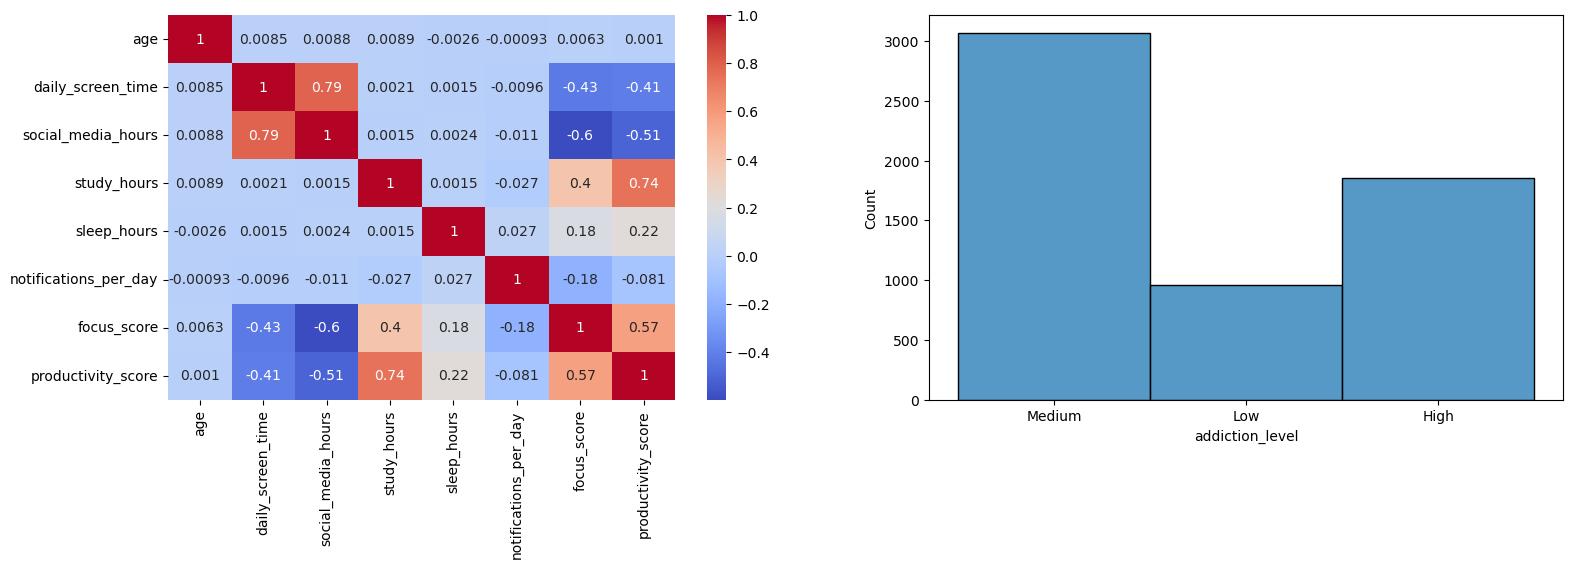

In [3]:
plt.figure(figsize=(18, 5))
plt.subplot(121)
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.subplot(122)
sns.histplot(df['addiction_level'])
plt.show()

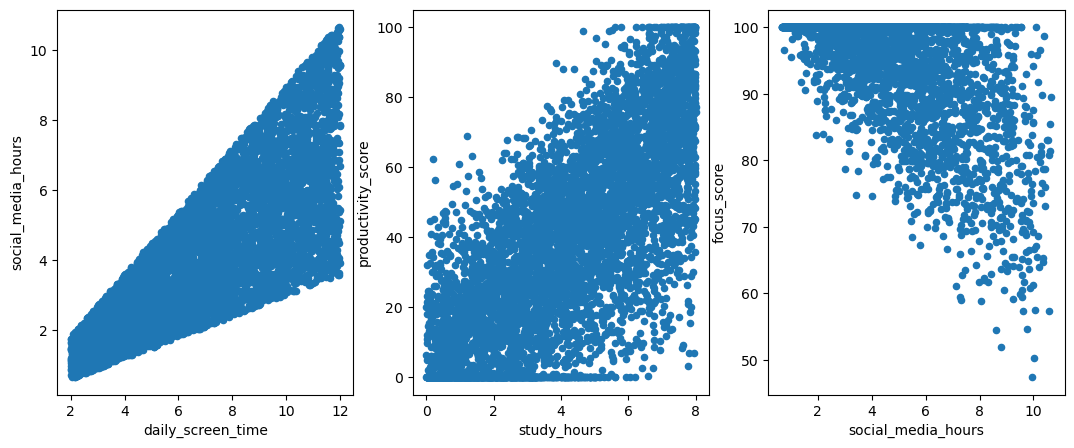

In [9]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(13, 5))
df.plot.scatter('daily_screen_time', 'social_media_hours', ax=ax1)
df.plot.scatter('study_hours', 'productivity_score', ax=ax2)
df.plot.scatter('social_media_hours', 'focus_score', ax=ax3)
plt.show()


* Clearly `addiction_level` quantity was based of `social_media_hours` in one way or another.
* Number of people with low productivity score drops clearly with addiction level.
* Third plot show no dependency of sleep hours, maybe grouping will give more info.

<Axes: xlabel='sleep_hours', ylabel='productivity_score'>

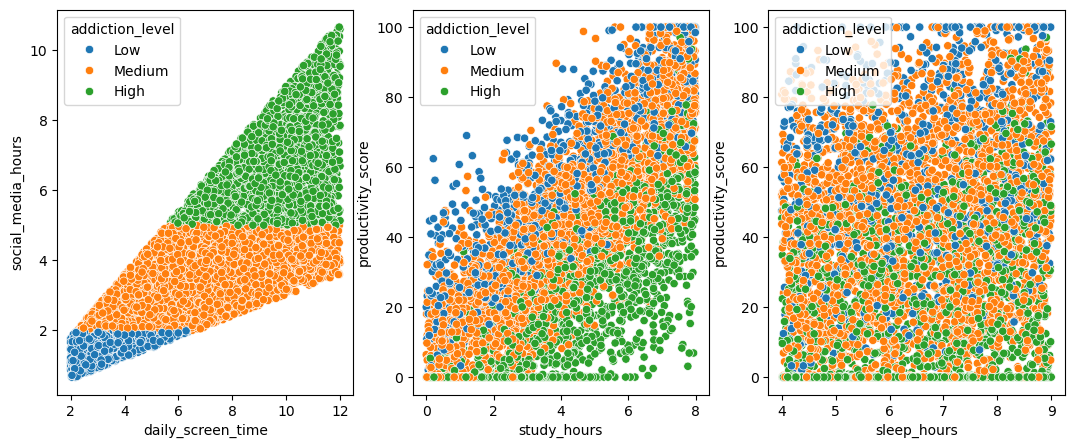

In [28]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(13, 5))
sns.scatterplot(x='daily_screen_time', y='social_media_hours', data=df, 
    hue='addiction_level', hue_order=['Low', 'Medium', 'High'], ax=ax1)
sns.scatterplot(x='study_hours', y='productivity_score', data=df, 
    hue='addiction_level', hue_order=['Low', 'Medium', 'High'], ax=ax2)
sns.scatterplot(x='sleep_hours', y='productivity_score', data=df,
    hue='addiction_level', hue_order=['Low', 'Medium', 'High'], ax=ax3)

In [ ]:
df['sleep_category'] = pd.qcut(df['sleep_hours'], 2, labels=['Below 6.5h', 'Over 6.5h'])
print(df['sleep_range'].unique())

[(6.525, 9.0], (3.999, 6.525], NaN]
Categories (2, interval[float64, right]): [(3.999, 6.525] < (6.525, 9.0]]
